Accuracy is considered a good metrics but usually we cannot use in the real world. This may arrise due to various reasons like class imbalance to name some.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported")

Libraries imported


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

knn = KNeighborsClassifier(n_neighbors=7)

df = pd.read_csv('data/telecom_churn_clean.csv')
df.head(10)

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
5,5,118,510,1,0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,0
6,6,121,510,0,1,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0
7,7,147,415,1,0,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,0
8,8,117,408,0,0,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,0
9,9,141,415,1,1,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,0


In [12]:
# Specifying X and Y values
X = df[['total_day_charge','total_eve_charge']].values
y = df['churn'].values

print(X.shape, y.shape)


(3333, 2) (3333,)


In [16]:
X_train, X_test, y_train ,y_test = train_test_split(X,y,test_size=0.4,random_state=42)

knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

In [17]:
print(confusion_matrix(y_test,y_pred))

[[1111   27]
 [ 142   54]]


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1138
           1       0.67      0.28      0.39       196

    accuracy                           0.87      1334
   macro avg       0.78      0.63      0.66      1334
weighted avg       0.85      0.87      0.85      1334



## Logistic Regression and ROC Curve

Logistic regression is used as a classifier rather than an regression. Its mainly used for binary classification. For this we will use the diabetes prediction.

In [ ]:
from sklearn.linear_model import LogisticRegression
 
diabetes_df = pd.read_csv('data/diabetes_clean.csv')
diabetes_df.head(10)

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [20]:
X = diabetes_df[['glucose','diastolic','bmi']]
y = diabetes_df[['diabetes']]

In [21]:
X_train, X_test, y_train ,y_test = train_test_split(X,y,test_size=0.4,random_state=42)



logReg = LogisticRegression()

logReg.fit(X_train,y_train)
y_pred = logReg.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [23]:
y_pred_probs = logReg.predict_proba(X_test)[:,1]
print(y_pred_probs[0])

0.20119168324622905


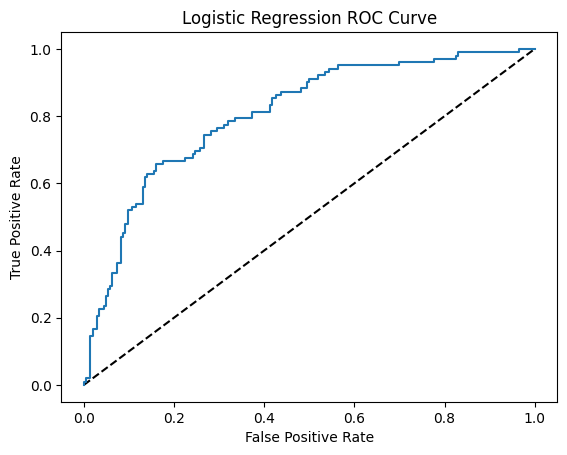

In [24]:
from sklearn.metrics import roc_curve
fpr, tpr, theresholds = roc_curve(y_test, y_pred_probs)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.show()


In [25]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test,y_pred_probs))

0.8057300590138968


In [28]:
# Calculate the confusion matrix
print(confusion_matrix(y_test, y_pred))

# Calculate the classification report
print(classification_report(y_test, y_pred))


[[179  27]
 [ 44  58]]
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       206
           1       0.68      0.57      0.62       102

    accuracy                           0.77       308
   macro avg       0.74      0.72      0.73       308
weighted avg       0.76      0.77      0.76       308



## Hyperparameter Tunning

* Note that while predicting Ridge/Lasso Regression we use Alpha.
* Also for KNN we used n_neighbors
* Hyperparameters : Parameters we specify before fitting the model.
* Fundemamental step is to choose the correct value for hyperparemeter this is called hyperparemeter tunning.
* When doing this it is essential to use cross -validation to avoid overfitting to the test set.

#### Grid Search cross validation:
As simple as the name suggests we create a grid of hyperaparameters that we can each test for each run. Lets perform Regression on a simple sales data to understand more on this:

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split,GridSearchCV, KFold


df = pd.read_csv('data/advertising_and_sales_clean.csv')
df.head(10)

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18
5,29000.0,9614.38,1027.16,Mega,105889.15
6,55000.0,24893.81,4273.60,Micro,198679.82
7,31000.0,17355.04,2289.85,Nano,108733.93
8,76000.0,24648.90,7130.12,Macro,270189.40
9,13000.0,431.13,2229.42,Mega,48280.58


In [39]:
X = df[['tv', 'radio', 'social_media']]
y = df['sales']

X_train, X_test, y_train ,y_test = train_test_split(X,y,test_size=0.4,random_state=42)


In [40]:
kf = KFold(n_splits=5, shuffle=True,random_state=42)
param_grid = {"alpha":np.arange(0.001,1, 10),
               "solver":["sage","lsqr"] }

ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv = kf)
ridge_cv.fit(X_train,y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Ridge(),
             param_grid={'alpha': array([0.001]), 'solver': ['sage', 'lsqr']})

In [42]:
print(ridge_cv.best_params_, ridge_cv.best_score_)

{'alpha': np.float64(0.001), 'solver': 'lsqr'} 0.9989812869945242


### Limitations and an alternative approach

* 3-fold cross-validation , 1 hyperparemeter, 10 total values = 30 fits
* 10-fold cross-validation , 3 hyperparemeter, 30 total values = 900 fits


### Alternative Approach

* RandomizedSearchCV will randomly pick the appropriate values from the grid instead for all the values.

In [44]:
from sklearn.model_selection import RandomizedSearchCV
kf = KFold(n_splits=5, shuffle=True,random_state=42)
param_grid = {"alpha":np.arange(0.001,1, 10),
               "solver":["sage","lsqr"] }

ridge = Ridge()
ridge_cv = RandomizedSearchCV(ridge, param_grid, cv = kf, n_iter=2)
ridge_cv.fit(X_train,y_train)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Ridge(), n_iter=2,
                   param_distributions={'alpha': array([0.001]),
                                        'solver': ['sage', 'lsqr']})

In [45]:
print(ridge_cv.best_params_, ridge_cv.best_score_)

{'solver': 'lsqr', 'alpha': np.float64(0.001)} 0.9989812869945242


In [46]:
test_score = ridge_cv.score(X_test, y_test)
print(test_score)

0.9990031277666227
